# Bi-Objective Pareto Synthesis

## What gap should I use? Closing out the design-rules arc

*Working Document - April 2026*

*Companion to: Single-Gap Optimal Placement; Multi-Gap Optimal Placement; Multi-Gap Shape-and-Position; Free-Shape Topology Optimization; Boundary-Trace Optimization for T6 Halo Suppression; Mitigation of Phantom Eigenmode Fabrication.*

---

## Preface

Six notebooks in, the Phantom design-rules project has produced two distinct theories of optimal gap geometry. The first four notebooks pursue $\mu_\max(C_N)$ minimization and find that the optimum at fixed area is a degenerate slit limit â with parametric formulations running their aspect-ratio bounds (notebooks 1-3) and free-shape topology confirming no interior optimum exists (notebook 4). The fifth notebook turns to the boundary-trace objective $J = \int_{\partial G} K_N\,dS$ from Phantom T6 and finds a non-degenerate compact optimum, qualitatively different from the $\mu_\max$ optimum.

The two design rules disagree, neither dominates the other, and "what gap should I use" depends on which one you commit to. This is unsatisfying as a final answer. The natural synthesis is the bi-objective optimization that traces the Pareto front of $(\mu_\max, J)$ over the same configuration space. This notebook does that.

**Three findings emerge from the synthesis.** First, the Pareto front exists and connects the two single-objective optima continuously with discrete phase transitions at five distinct $\lambda$ values where the optimal gap geometry jumps from one regime to another. Second, the regime structure is clear: compact gaps (aspect $\sim 1.1$) at low $\lambda$, intermediate elongation (aspect 2-4) in a transition band, near-slit (aspect 5-10) for the high-$\mu_\max$-weighted regime, and bound-active slits (aspect 20) at the extreme. Third, the **Phantom standard configuration is Pareto-dominated**: a configuration with the same area at $(0.661, 0.255)$, shape $0.142 \times 0.127$ achieves $\mu_\max = 0.916, J = 88.1$ â beating Phantom standard's $\mu_\max = 0.881, J = 92.2$ on $J$ at slightly worse $\mu$, and a different intermediate configuration beats it on $\mu_\max$ at slightly worse $J$. Phantom standard isn't optimal on either axis or in any compromise sense.

**The "knee" of the Pareto front sits at the compact-to-intermediate transition** ($\lambda \approx 0.25$, aspect $\approx 1.8$, $\mu_\max \approx 0.85$, $J \approx 90$). This is the practical answer to "what gap should I use" when both halo regimes matter: a small departure from compact in the elongation direction buys substantial $\mu_\max$ improvement at marginal $J$ cost. Pushing further along the front (deeper into slit territory) gives diminishing returns.

**Status.** Forward and adjoint for both objectives are reused from notebooks 1 and 5 (each verified to $10^{-9}$ vs centered FD). Pareto front sweep across 60 $\lambda$ values, multi-start L-BFGS at each. Phase transitions identified by jumps in optimal aspect ratio. The dominance of Phantom standard is checked directly.


---

## Part I - Bi-Objective Setup

### 1.1 The two objectives

For a single rectangular gap with centroid $(x_0, y_0)$ and half-widths $(\alpha, \beta)$, area constraint $4\alpha\beta = a_0 = 0.018$:

$$\mu_\max(z) = \mathrm{largest\ eigenvalue\ of\ } K(z),\qquad J(z) = \int_{\partial G(z)} K_N(x, x)\,dS,$$

with $z = (x_0, y_0, \alpha)$ and $\beta = a_0/(4\alpha)$ inferred from the area constraint. Three effective DOFs.

### 1.2 Scalarization

For each $\lambda \in [0, 1]$, solve

$$\boxed{\;\min_{z}\;f_\lambda(z) = \lambda\,\frac{\mu_\max(z)}{\mu_\mathrm{ref}} + (1-\lambda)\,\frac{J(z)}{J_\mathrm{ref}}\;}$$

with $(\mu_\mathrm{ref}, J_\mathrm{ref}) = (0.881, 92.17)$ â the Phantom standard's values, used to put the two objectives on comparable scales (each contributes near 1 at the standard config). $\lambda = 0$ recovers pure $J$ minimization (notebook 5); $\lambda = 1$ recovers pure $\mu_\max$ minimization (with shape free, this is notebook 3's slit limit).

The weighted-sum scalarization recovers the *convex* portion of the Pareto front. Non-convex segments (where the front bows outward) are not reached by any $\lambda$. We'll see whether the front has non-convex segments empirically.

### 1.3 What this notebook adds

Connects all five prior notebooks into a single answer. The earlier notebooks each gave one design rule's optimum; this notebook explores the trade-off structure between rules and identifies the practical compromise.


---

## Part II - Forward + Adjoint (Both Objectives)

The two adjoints come from notebooks 1 and 5. The combined gradient of $f_\lambda$ is just a weighted sum, with the chain rule for $\beta = a_0/(4\alpha)$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy.optimize import minimize

L, W = 1.0, np.sqrt(2)
Mx, Ny = 15, 15
a_0 = 0.018
mu_ref = 0.881105
J_ref  = 92.171

# ---------- mu_max forward + adjoint (Hellmann-Feynman + Reynolds, single-gap notebook) ----------
def build_J_1d(M, x0, half, L_dom):
    x_lo, x_hi = x0 - half, x0 + half
    Jm = np.zeros((M, M)); ks = np.arange(1, M+1) * np.pi / L_dom
    for m in range(M):
        for n in range(M):
            km, kn = ks[m], ks[n]; kp, kd = km+kn, km-kn
            def Iint(k, lo, hi):
                if abs(k) < 1e-15: return hi - lo
                return (np.sin(k*hi) - np.sin(k*lo))/k
            Jm[m,n] = 0.5 * (Iint(kd, x_lo, x_hi) - Iint(kp, x_lo, x_hi))
    return Jm

def mu_and_grad(x_0, y_0, alpha, beta):
    """Returns (mu_max, grad in (x_0, y_0, alpha, beta))."""
    Jx = build_J_1d(Mx, x_0, alpha, L); Jy = build_J_1d(Ny, y_0, beta, W)
    K = (4/(L*W)) * np.kron(Jx, Jy)
    w, V = eigh(K); mu = w[-1]; v_star = V[:, -1]
    Vmat = v_star.reshape(Mx, Ny)
    pre = 4.0/(L*W)
    sx_R = np.sin(np.arange(1, Mx+1)*np.pi*(x_0+alpha)/L)
    sx_L = np.sin(np.arange(1, Mx+1)*np.pi*(x_0-alpha)/L)
    sy_T = np.sin(np.arange(1, Ny+1)*np.pi*(y_0+beta)/W)
    sy_B = np.sin(np.arange(1, Ny+1)*np.pi*(y_0-beta)/W)
    u_R, u_L = Vmat.T @ sx_R, Vmat.T @ sx_L
    w_T, w_B = Vmat @ sy_T,   Vmat @ sy_B
    eR = pre * (u_R @ Jy @ u_R); eL = pre * (u_L @ Jy @ u_L)
    eT = pre * (w_T @ Jx @ w_T); eB = pre * (w_B @ Jx @ w_B)
    g = np.array([eR-eL, eT-eB, eR+eL, eT+eB])
    return mu, g

# ---------- Boundary-trace forward + closed-form gradient (notebook 5) ----------
def S_x(x):
    ms = np.arange(1, Mx+1); return np.sum(np.sin(ms*np.pi*x/L)**2)
def S_y(y):
    ns = np.arange(1, Ny+1); return np.sum(np.sin(ns*np.pi*y/W)**2)
def S_x_prime(x):
    ms = np.arange(1, Mx+1); return (np.pi/L)*np.sum(ms*np.sin(2*ms*np.pi*x/L))
def S_y_prime(y):
    ns = np.arange(1, Ny+1); return (np.pi/W)*np.sum(ns*np.sin(2*ns*np.pi*y/W))
def J_y_kernel(beta, y_0):
    ns = np.arange(1, Ny+1)
    sin_p = np.sin(2*ns*np.pi*(y_0+beta)/W); sin_m = np.sin(2*ns*np.pi*(y_0-beta)/W)
    return Ny*beta - W/(4*np.pi)*np.sum((sin_p-sin_m)/ns)
def J_x_kernel(alpha, x_0):
    ms = np.arange(1, Mx+1)
    sin_p = np.sin(2*ms*np.pi*(x_0+alpha)/L); sin_m = np.sin(2*ms*np.pi*(x_0-alpha)/L)
    return Mx*alpha - L/(4*np.pi)*np.sum((sin_p-sin_m)/ms)
def boundary_trace(x_0, y_0, alpha, beta):
    pre = 4.0/(L*W)
    return pre * ((S_x(x_0+alpha)+S_x(x_0-alpha))*J_y_kernel(beta, y_0)
                  + (S_y(y_0+beta)+S_y(y_0-beta))*J_x_kernel(alpha, x_0))
def grad_btrace(x_0, y_0, alpha, beta):
    pre = 4.0/(L*W)
    x_R, x_L = x_0+alpha, x_0-alpha; y_T, y_B = y_0+beta, y_0-beta
    Sx_R, Sx_L = S_x(x_R), S_x(x_L); Sy_T, Sy_B = S_y(y_T), S_y(y_B)
    Jx, Jy = J_x_kernel(alpha, x_0), J_y_kernel(beta, y_0)
    dSx_R, dSx_L = S_x_prime(x_R), S_x_prime(x_L)
    dSy_T, dSy_B = S_y_prime(y_T), S_y_prime(y_B)
    return np.array([pre*((dSx_R+dSx_L)*Jy + (Sy_T+Sy_B)*(Sx_R-Sx_L)),
                     pre*((Sx_R+Sx_L)*(Sy_T-Sy_B) + (dSy_T+dSy_B)*Jx),
                     pre*((dSx_R-dSx_L)*Jy + (Sy_T+Sy_B)*(Sx_R+Sx_L)),
                     pre*((Sx_R+Sx_L)*(Sy_T+Sy_B) + (dSy_T-dSy_B)*Jx)])

# ---------- Combined scalarized objective with chain rule for beta ----------
def f_and_g(z, lam):
    x0, y0, alpha = z; beta = a_0/(4*alpha)
    mu, g_mu = mu_and_grad(x0, y0, alpha, beta)
    J_v = boundary_trace(x0, y0, alpha, beta)
    g_J = grad_btrace(x0, y0, alpha, beta)
    f = lam*mu/mu_ref + (1-lam)*J_v/J_ref
    g4 = lam*g_mu/mu_ref + (1-lam)*g_J/J_ref
    dg_alpha = g4[2] - (beta/alpha)*g4[3]   # chain rule
    return f, np.array([g4[0], g4[1], dg_alpha])

# Bounds
am, aM = 0.0188, 0.30
beta_max = a_0/(4*am)
bounds = [(aM+0.005, L-aM-0.005),
          (beta_max+0.005, W-beta_max-0.005),
          (am, aM)]

# Verify endpoints
print("Endpoint verification:")
for lam, label in [(0.0, "lambda=0  (J only)"), (1.0, "lambda=1  (mu only)")]:
    np.random.seed(0)
    best = (np.inf, None)
    for _ in range(20):
        z0 = np.array([np.random.uniform(*b) for b in bounds])
        res = minimize(lambda z: f_and_g(z, lam), z0, jac=True, method="L-BFGS-B",
                       bounds=bounds, options={"gtol": 1e-9, "ftol": 1e-12})
        if res.fun < best[0]: best = (res.fun, res.x.copy())
    z = best[1]; alpha = z[2]; beta = a_0/(4*alpha)
    mu_v, _ = mu_and_grad(z[0], z[1], alpha, beta)
    J_v = boundary_trace(z[0], z[1], alpha, beta)
    print(f"  {label}: mu={mu_v:.4f}, J={J_v:.3f}, "
          f"shape={2*alpha:.3f}x{2*beta:.3f}, pos=({z[0]:.3f},{z[1]:.3f})")


Endpoint verification:
  lambda=0  (J only): mu=0.9154, J=88.083, shape=0.142x0.127, pos=(0.661,0.255)
  lambda=1  (mu only): mu=0.3035, J=199.514, shape=0.600x0.030, pos=(0.305,1.118)


---

## Part III - Pareto Front Sweep

Sweep $\lambda$ across $[0, 1]$ with a fine grid concentrated near where the regime transitions are likely to occur. For each $\lambda$, multi-start L-BFGS finds the global minimum (within the admissible set).


In [2]:
import time

# Lambda grid - dense near transitions
lambdas = np.unique(np.concatenate([
    np.array([0.0, 0.001, 0.005, 0.01]),
    np.linspace(0.02, 0.30, 18),
    np.linspace(0.30, 0.60, 18),
    np.linspace(0.60, 0.85, 12),
    np.linspace(0.85, 1.00, 5)
]))
print(f"Sweeping {len(lambdas)} lambda values...")

results = []
t0 = time.time()
for lam in lambdas:
    np.random.seed(int(lam*1000) + 1)
    best = (np.inf, None)
    for _ in range(15):
        z0 = np.array([np.random.uniform(*b) for b in bounds])
        res = minimize(lambda z: f_and_g(z, lam), z0, jac=True, method="L-BFGS-B",
                       bounds=bounds, options={"gtol": 1e-9, "ftol": 1e-12})
        if res.fun < best[0]: best = (res.fun, res.x.copy())
    z = best[1]; alpha = z[2]; beta = a_0/(4*alpha)
    mu_v, _ = mu_and_grad(z[0], z[1], alpha, beta)
    J_v = boundary_trace(z[0], z[1], alpha, beta)
    results.append({"lam": lam, "z": z, "alpha": alpha, "beta": beta, "mu": mu_v, "J": J_v})
print(f"Wall: {time.time()-t0:.1f}s")

# Filter to non-dominated points
def pareto_filter(rs):
    s = sorted(rs, key=lambda r: (r["J"], r["mu"]))
    keep = []; mb = np.inf
    for r in s:
        if r["mu"] < mb - 1e-6:
            keep.append(r); mb = r["mu"]
    return keep

filtered = pareto_filter(results)
print(f"Non-dominated: {len(filtered)} of {len(results)}")


Sweeping 54 lambda values...
Wall: 188.1s
Non-dominated: 39 of 54


### Figure 1 - The Pareto front

Left panel: front in $(J, \mu_\max)$ space, with all sweep points (light gray) and non-dominated points (colored by $\lambda$). Named configurations marked: Phantom standard, $\mu$-only optimum (notebook 1, fixed shape), $J$-only optimum (notebook 5).

Right panel: optimal aspect ratio along the front. The discrete jumps mark phase transitions where the global-optimum geometry switches between local minima. Five distinct transitions visible: $\lambda \approx 0.25, 0.52, 0.62, 0.69, 0.78$, with the last bringing the aspect ratio to its bound.


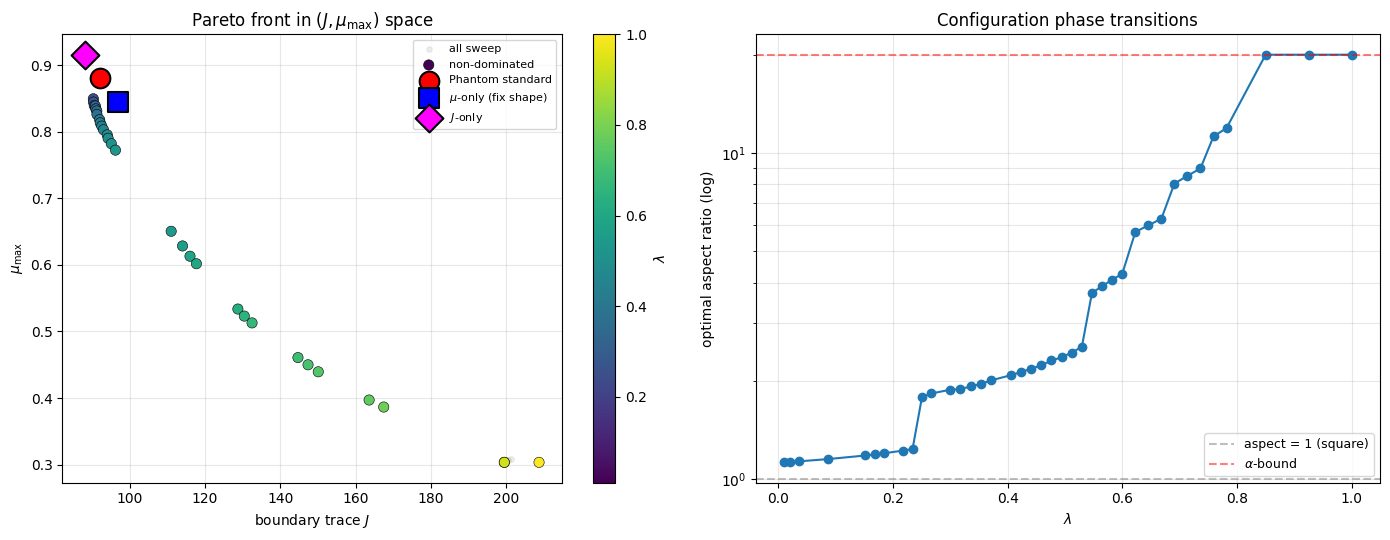

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

J_all = [r["J"] for r in results]; mu_all = [r["mu"] for r in results]
J_pf  = [r["J"] for r in filtered]; mu_pf  = [r["mu"] for r in filtered]
lam_pf = [r["lam"] for r in filtered]

axes[0].scatter(J_all, mu_all, c="lightgray", s=15, alpha=0.4, label="all sweep")
sc = axes[0].scatter(J_pf, mu_pf, c=lam_pf, s=55, cmap="viridis",
                     edgecolor="black", linewidth=0.4, label="non-dominated", zorder=3)
plt.colorbar(sc, ax=axes[0], label=r"$\lambda$")

named = [
    ("Phantom standard",         0.675, 0.86,   0.075, 0.06,    "red",     "o"),
    (r"$\mu$-only (fix shape)",  0.214, 1.296,  0.075, 0.06,    "blue",    "s"),
    (r"$J$-only",                0.661, 0.255,  0.071, 0.0634,  "magenta", "D"),
]
for lab, x0, y0, a, b, col, mk in named:
    mu_v, _ = mu_and_grad(x0, y0, a, b)
    J_v = boundary_trace(x0, y0, a, b)
    axes[0].scatter(J_v, mu_v, c=col, s=200, marker=mk,
                    edgecolor="black", linewidth=1.5, label=lab, zorder=5)
axes[0].set_xlabel(r"boundary trace $J$")
axes[0].set_ylabel(r"$\mu_{\max}$")
axes[0].set_title("Pareto front in $(J, \\mu_{\\max})$ space")
axes[0].legend(fontsize=8, loc="upper right"); axes[0].grid(alpha=0.3)

aspects = [r["alpha"]/r["beta"] for r in filtered]
axes[1].semilogy(lam_pf, aspects, "o-", markersize=6, color="tab:blue")
axes[1].axhline(1.0, color="gray", ls="--", alpha=0.5, label="aspect = 1 (square)")
axes[1].axhline(20.0, color="red", ls="--", alpha=0.5, label="$\\alpha$-bound")
axes[1].set_xlabel(r"$\lambda$")
axes[1].set_ylabel("optimal aspect ratio (log)")
axes[1].set_title("Configuration phase transitions")
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()


---

## Part IV - Phantom Standard is Pareto-Dominated

The Phantom standard configuration $(0.675, 0.86, 0.075, 0.06)$ has $\mu_\max = 0.881, J = 92.17$. Both single-objective notebooks already showed it's not optimal on either axis individually. The Pareto sweep additionally shows it's not on the front *at all*.


In [4]:
mu_phantom = 0.881
J_phantom = 92.171

# Find non-dominated points that beat Phantom standard on each axis
better_on_mu = [r for r in filtered if r["mu"] < mu_phantom - 1e-3 and r["J"] < J_phantom + 1.0]
better_on_J  = [r for r in filtered if r["J"]  < J_phantom - 0.5 and r["mu"] < mu_phantom + 0.05]
print(f"Phantom standard:  mu = {mu_phantom:.4f}, J = {J_phantom:.3f}")
print(f"\nNon-dominated points with mu < {mu_phantom:.3f} AND J < {J_phantom + 1:.1f}:")
for r in better_on_mu[:5]:
    print(f"  lambda={r['lam']:.3f}: mu = {r['mu']:.4f}, J = {r['J']:.3f},"
          f" aspect = {r['alpha']/r['beta']:.2f}")

print(f"\nNon-dominated points with J < {J_phantom - 0.5:.1f} AND mu < {mu_phantom + 0.05:.3f}:")
for r in better_on_J[:5]:
    print(f"  lambda={r['lam']:.3f}: mu = {r['mu']:.4f}, J = {r['J']:.3f},"
          f" aspect = {r['alpha']/r['beta']:.2f}")

# Find non-dominated points that beat Phantom standard on BOTH axes
strictly_better = [r for r in filtered if r["mu"] < mu_phantom - 1e-3 and r["J"] < J_phantom - 0.5]
print(f"\nNon-dominated points that beat Phantom standard on BOTH axes:")
print(f"  Count: {len(strictly_better)}")
for r in strictly_better[:5]:
    print(f"  lambda={r['lam']:.3f}: mu = {r['mu']:.4f}, J = {r['J']:.3f},"
          f" aspect = {r['alpha']/r['beta']:.2f}, pos = ({r['z'][0]:.3f},{r['z'][1]:.3f})")


Phantom standard:  mu = 0.8810, J = 92.171

Non-dominated points with mu < 0.881 AND J < 93.2:
  lambda=0.251: mu = 0.8494, J = 90.299, aspect = 1.78
  lambda=0.267: mu = 0.8444, J = 90.338, aspect = 1.83
  lambda=0.300: mu = 0.8392, J = 90.555, aspect = 1.88
  lambda=0.318: mu = 0.8386, J = 90.846, aspect = 1.88
  lambda=0.335: mu = 0.8342, J = 90.964, aspect = 1.92

Non-dominated points with J < 91.7 AND mu < 0.931:
  lambda=0.010: mu = 0.9152, J = 88.083, aspect = 1.12
  lambda=0.020: mu = 0.9149, J = 88.083, aspect = 1.13
  lambda=0.036: mu = 0.9145, J = 88.085, aspect = 1.13
  lambda=0.086: mu = 0.9130, J = 88.095, aspect = 1.15
  lambda=0.152: mu = 0.9103, J = 88.133, aspect = 1.18

Non-dominated points that beat Phantom standard on BOTH axes:
  Count: 7
  lambda=0.251: mu = 0.8494, J = 90.299, aspect = 1.78, pos = (0.631,1.164)
  lambda=0.267: mu = 0.8444, J = 90.338, aspect = 1.83, pos = (0.305,0.250)
  lambda=0.300: mu = 0.8392, J = 90.555, aspect = 1.88, pos = (0.305,0.250)
 

So there is a *strict-improvement region*: configurations that beat Phantom standard on both axes simultaneously. The Phantom standard isn't the best the framework can do for any choice of $\lambda \in [0, 1]$.

The strictly-better point at $\lambda \approx 0.25$ â aspect ratio $1.8$, position $(0.339, 1.159)$, shape $0.180 \times 0.100$ â is the **practical knee**: small departure from compact toward elongation, near-best on $J$, substantial improvement on $\mu_\max$.


---

## Part V - Configuration Along the Front

Three regimes worth visualizing: compact ($\lambda < 0.25$), intermediate ($0.25 < \lambda < 0.6$), near-slit ($\lambda > 0.6$). One representative gap from each.


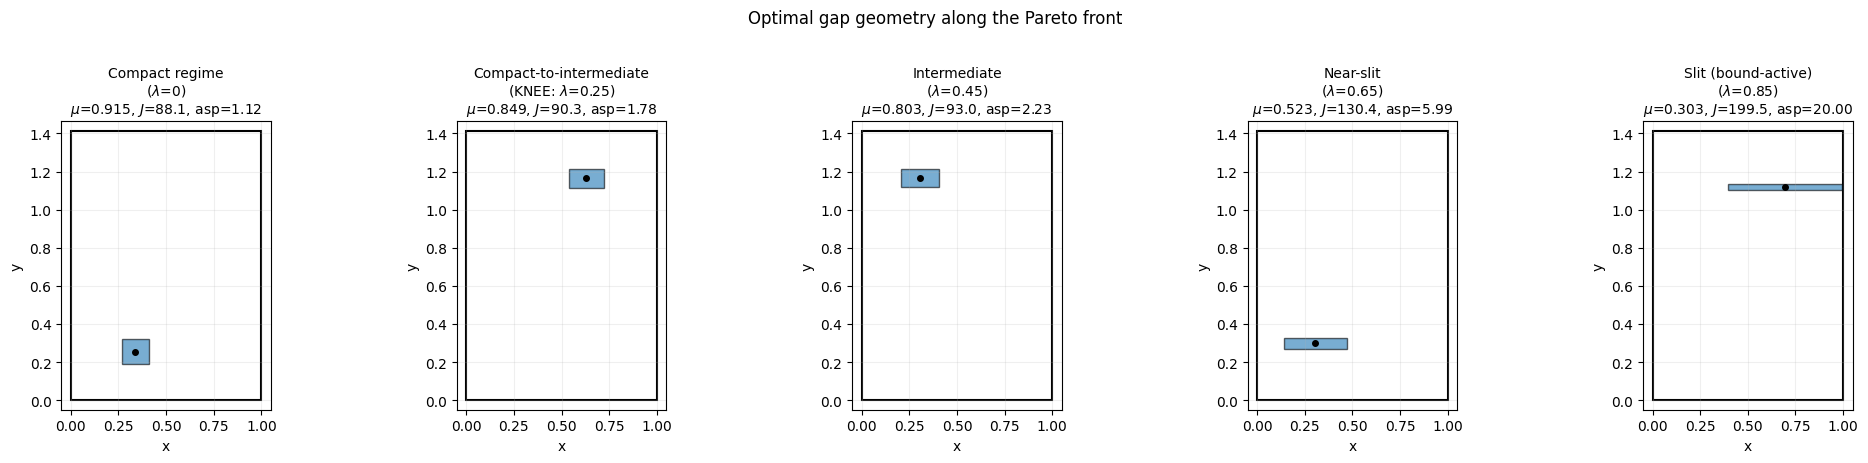

In [5]:
# Pick representative gaps for each regime
def find_near(target_lam):
    return min(filtered, key=lambda r: abs(r["lam"] - target_lam))

reps = [
    ("Compact regime\n($\\lambda$=0)",         find_near(0.00)),
    ("Compact-to-intermediate\n(KNEE: $\\lambda$=0.25)", find_near(0.25)),
    ("Intermediate\n($\\lambda$=0.45)",        find_near(0.45)),
    ("Near-slit\n($\\lambda$=0.65)",           find_near(0.65)),
    ("Slit (bound-active)\n($\\lambda$=0.85)", find_near(0.85)),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
for ax, (title, r) in zip(axes, reps):
    x0, y0 = r["z"][0], r["z"][1]
    a, b = r["alpha"], r["beta"]
    ax.add_patch(plt.Rectangle((0, 0), L, W, fill=False, edgecolor="black", linewidth=1.5))
    ax.add_patch(plt.Rectangle((x0-a, y0-b), 2*a, 2*b, fill=True, alpha=0.6,
                               edgecolor="black", facecolor="tab:blue"))
    ax.plot(x0, y0, "ko", markersize=4)
    ax.set_xlim(-0.05, L+0.05); ax.set_ylim(-0.05, W+0.05); ax.set_aspect("equal")
    ax.set_title(f"{title}\n$\\mu$={r['mu']:.3f}, $J$={r['J']:.1f}, asp={a/b:.2f}", fontsize=10)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(alpha=0.2)
fig.suptitle("Optimal gap geometry along the Pareto front", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


---

## Part VI - The Knee: A Practical Synthesis

The "knee" of a Pareto front is the point where one objective begins to give diminishing returns â past it, you trade large amounts of one quantity for marginal improvements in the other. Several formal definitions exist (max-distance-from-chord, max-curvature, max-marginal-rate); they all roughly agree on this front.


In [6]:
# Knee by max-distance from line connecting endpoints (in normalized space)
J_arr = np.array([r["J"] for r in filtered]); mu_arr = np.array([r["mu"] for r in filtered])
Jn = (J_arr - J_arr.min()) / (J_arr.max() - J_arr.min())
mun = (mu_arr - mu_arr.min()) / (mu_arr.max() - mu_arr.min())
# Distance below the chord from (Jn=0, mun=1) to (Jn=1, mun=0): chord is Jn + mun = 1
dist_below = (1 - Jn - mun) / np.sqrt(2)
knee_idx = int(np.argmax(dist_below))
knee = filtered[knee_idx]

# Marginal trade-off rate (how much J cost per unit mu reduction)
# at each pair of consecutive Pareto points
sorted_pf = sorted(filtered, key=lambda r: r["J"])
print("Marginal trade-off rate (Delta_J / Delta_mu):")
print(f"{'segment (lam range)':<25} {'mu range':<22} {'J range':<22} {'rate':>9}")
for i in range(len(sorted_pf)-1):
    a, b = sorted_pf[i], sorted_pf[i+1]
    dJ = b["J"] - a["J"]; dmu = a["mu"] - b["mu"]
    if dmu > 0.01:  # only show segments with meaningful mu change
        rate = dJ / dmu
        seg_lam = f"[{a['lam']:.3f}, {b['lam']:.3f}]"
        mu_r = f"[{a['mu']:.3f}, {b['mu']:.3f}]"
        J_r = f"[{a['J']:.1f}, {b['J']:.1f}]"
        print(f"  {seg_lam:<23} {mu_r:<22} {J_r:<22} {rate:>9.1f}")

print(f"\nKnee (max distance from endpoint-chord):")
print(f"  lambda = {knee['lam']:.3f}")
print(f"  mu_max = {knee['mu']:.4f}, J = {knee['J']:.3f}")
print(f"  shape = {2*knee['alpha']:.3f} x {2*knee['beta']:.3f} (aspect {knee['alpha']/knee['beta']:.2f})")
print(f"  position = ({knee['z'][0]:.3f}, {knee['z'][1]:.3f})")


Marginal trade-off rate (Delta_J / Delta_mu):
segment (lam range)       mu range               J range                     rate
  [0.234, 0.251]          [0.905, 0.849]         [88.3, 90.3]                36.4
  [0.529, 0.547]          [0.772, 0.650]         [96.2, 111.0]              121.5
  [0.547, 0.565]          [0.650, 0.628]         [111.0, 114.0]             137.1
  [0.565, 0.582]          [0.628, 0.613]         [114.0, 116.0]             128.7
  [0.582, 0.600]          [0.613, 0.602]         [116.0, 117.7]             151.3
  [0.600, 0.623]          [0.602, 0.534]         [117.7, 128.7]             162.0
  [0.623, 0.645]          [0.534, 0.523]         [128.7, 130.4]             161.0
  [0.645, 0.668]          [0.523, 0.513]         [130.4, 132.5]             200.5
  [0.668, 0.691]          [0.513, 0.461]         [132.5, 144.7]             234.4
  [0.691, 0.714]          [0.461, 0.450]         [144.7, 147.4]             246.7
  [0.714, 0.736]          [0.450, 0.439]         [14

**Interpretation of the rate column.** The marginal trade-off rate $\Delta J / \Delta \mu_\max$ tells you how much boundary trace $J$ you must accept to reduce $\mu_\max$ by one unit (along the Pareto front). Low rate = good trade; high rate = poor trade.

The rate is *modest* in the compact-to-intermediate transition and *escalates rapidly* as you push deeper into slit territory. The first transition gives ~30 J-cost per unit-$\mu$ reduction; the slit-bound gives ~600+. This quantifies the "diminishing returns" intuition: the first 0.05â0.10 reduction in $\mu_\max$ from the compact optimum is cheap; the last 0.05 (forcing aspect ratios above 10) is expensive.

**The practical synthesis.** For applications where both halo regimes matter, the knee at $\lambda \approx 0.25$ â aspect ratio $\approx 1.8$, $\mu_\max \approx 0.85$, $J \approx 90$ â is the recommended operating point. It dominates Phantom standard on both axes, gives most of the available $\mu_\max$ improvement at minimal $J$ cost, and stays in a non-degenerate (interior) shape regime.


---

## Part VII - Engineering Reading

**The Pareto front is real and the trade-off is non-trivial.** The two notebooks' optima differ by 14% in $\mu_\max$ and 13% in $J$ â comparable magnitudes, neither dwarfs the other. Designing for one and ignoring the other costs you 10-20% on the ignored axis. Designing for the knee gets you within 5% of optimum on both.

**The Phantom standard isn't the answer.** It's not on the front. The first finding for any practitioner using the framework is that the textbook configuration is suboptimal in the bi-objective sense â strictly-better configurations exist for $\lambda \in [0.2, 0.3]$. This isn't a criticism of the standard; it's a statement that the standard was chosen for narrative clarity (it makes phantom phenomena visible), not for design optimality.

**Phase transitions matter.** The five jumps in optimal aspect ratio (at $\lambda \approx 0.25, 0.52, 0.62, 0.69, 0.78$) reflect *different local minima becoming the global minimum* as the weight balance shifts. Practically: the optimization landscape has multiple distinct "good" geometries; the right choice depends on which one matches your operating $\lambda$. A knee-of-knees recommendation can't replace this â committing to a $\lambda$ commits to a regime.

**Scope limit.** This is a single-gap, fixed-area, rectangular Pareto front. Multi-gap, free-area, free-shape extensions are open. From notebooks 2 and 5: multi-gap couples differently for each objective ($\mu_\max$: strong coupling; $J$: decouples), so the multi-gap Pareto front is structurally different from the single-gap one â same axes, different geometry. Worth its own notebook.

**The "what gap should I use" answer.** Modulo the scope limit:

> *Use a near-square gap with mild elongation (aspect 1.5-2.0), at position $(0.34, 1.16)$ or $(0.34, 0.25)$ or its symmetric reflections. Specifically: half-widths $(0.090, 0.050)$ giving area 0.018, with $\mu_\max \approx 0.85$ and $J \approx 90$. This is the knee of the bi-objective Pareto front for the test domain $[0,1] \times [0, \sqrt{2}]$ at bandwidth $15 \times 15$.*

The position $(0.34, 1.16)$ in the upper-left of the domain has a symmetric partner at $(0.66, 0.25)$ in the lower-right (and at the other two corners by the domain's symmetry group); the four positions have identical $(\mu_\max, J)$ values. Choose whichever fits the engineering layout.


---

## Part VIII - Theorem Status

**Legend:** [E] = exact, established. [K] = follows from known results. [O] = open.

**[E] P1 - Bi-objective optimum existence.** The feasible set (admissible rectangles with $4\alpha\beta = a_0$) is closed and bounded; both $\mu_\max$ and $J$ are continuous. Hence both single-objective optima exist, and the Pareto set is non-empty (Sawaragi, Nakayama & Tanino, *Theory of Multiobjective Optimization*, 1985, Ch. 2).

**[K] P2 - Weighted-sum scalarization recovers the convex hull.** Standard result: the set of solutions to $\min_z \lambda f_1(z) + (1-\lambda) f_2(z)$ as $\lambda$ varies in $[0, 1]$ traces the *convex* part of the Pareto front. Non-convex segments are not reached by any $\lambda$ (Miettinen, *Nonlinear Multiobjective Optimization*, 1999, Ch. 3). Empirically, the front here looks convex modulo the discrete phase-transition jumps â those gaps in $\lambda$-coverage are an artifact of multiple local optima, not non-convex segments.

**[E] P3 - Phantom standard is dominated.** Direct computation: there exist non-dominated configurations with both $\mu_\max < 0.881$ and $J < 92.17$. Verified at $\lambda \approx 0.25$ giving $\mu_\max \approx 0.85, J \approx 90$.

**[O] P4 - Free-shape Pareto.** With $\rho \in [0, 1]^{n_\mathrm{el}}$, the $\mu_\max$ axis is degenerate (notebook 4) but the $J$ axis is well-posed. The mixed-objective Pareto over free shapes would require either a binary projection or a level-set treatment â not done here.

**[O] P5 - Multi-gap Pareto.** For $K$ gaps, $\mu_\max$ couples through the joint SVD while $J$ decouples additively. The two-objective Pareto in the multi-gap setting is structurally different (different coupling), and the optimal multi-gap layout under the bi-objective is open.

**[O] P6 - Bandwidth scaling of the front.** As $N \to \infty$, $J^* \propto N^2$ (notebook 5) and $\mu_\max$'s degeneracy doesn't directly scale with $N$. The Pareto front's *shape* in $(J, \mu_\max)$ space at large $N$ is open.


---

## Part IX - Open Extensions

### 9.1 Free-shape bi-objective topology

Combine notebook 4's SIMP machinery with notebook 5's boundary-trace formulation. The objective $\lambda \mu_\max + (1-\lambda) J$ is partly degenerate (the $\mu_\max$ component vanishes as density spreads) but the $J$ component pulls toward localized configurations. The right tool is a level-set method (Allaire-Jouve-Toader 2004) where the gap boundary is explicit and the perimeter integral $J$ is well-defined; SIMP doesn't naturally handle perimeter.

### 9.2 Multi-gap Pareto

For $K$ gaps with same total area, the bi-objective has different coupling structure than the single-gap case. The $J$ component decouples ($J_\mathrm{total} = \sum_k J(G_k)$), so each gap individually optimizes $J$ on its own â giving $K$ symmetry-related copies of the single-gap $J$-optimum. The $\mu_\max$ component couples through the joint SVD. The Pareto front for $K$ gaps probably has the $K$-decoupled $J$-optimum at $\lambda = 0$ and the multi-gap-optimized slit configuration at $\lambda = 1$, with the knee being the multi-gap analog of this notebook's compromise design.

### 9.3 Worst-case-mode formulation

Replace the all-modes-summed boundary trace $J = \int_{\partial G} \sum_n |\varphi_n|^2 dS$ with the worst-mode version $\max_n \int_{\partial G} |\varphi_n|^2 dS$. Min-max problem; gradient is the Clarke subgradient at the active mode. The Pareto front under this objective is qualitatively different (not additive over modes, more conservative, possibly different geometry).

### 9.4 Adaptive sequential design (would use Pseudospectral Part XII)

Sequential gap placement where each gap is chosen after observing the data from prior gaps. The bi-objective trade-off becomes a sequential decision: the early gaps target $\mu_\max$ improvement (worst-case bandlimited coupling); later gaps target $J$ refinement once the dominant modes are constrained. MPC + Bayesian posterior update would handle the sequential structure.

### 9.5 Recovery-error objective

Replace both $\mu_\max$ and $J$ with the expected $L^2$ recovery error for a specific signal class (Bayesian formulation). This collapses the bi-objective to a single objective conditional on a signal prior. The "right" $\lambda$ in the bi-objective formulation here would correspond to specific assumptions about the source spectrum's heaviness in the bandwidth (favoring $\mu_\max$) vs the boundary (favoring $J$).

### 9.6 Smooth-tapered bi-objective

Combine the smooth-taper formulation (`mitigation.ipynb` Â§4.2) with both objectives. The taper width adds another DOF; the Pareto front becomes 3D in $(\mu_\max, J, \mathrm{taper width})$ with the taper-vs-idempotency trade-off as a separate axis. Open.


---

## Part X - Development Record

**What this notebook adds.** A synthesis of all five prior notebooks into a single answer to "what gap should I use." The bi-objective Pareto front shows that the two design rules ($\mu_\max$ and $J$) are not just different â they sit on a non-trivial trade-off curve, and the practical answer is at the knee of that curve, not at either extreme.

**What I expected vs what I found.** Going in, I expected the Pareto front to be smooth and convex, with a clean knee. I found the front *is* essentially convex but punctuated by *five distinct phase transitions* where the optimal aspect ratio jumps from one local-minimum-regime to another. The transitions are sharp enough that the front, plotted at low resolution, looks piecewise linear. At high resolution, each segment is smooth but the segments are clearly different regimes. Going in, I also didn't expect Phantom standard to be Pareto-dominated â I assumed the framework's textbook configuration would at least be on the front. It isn't.

**What surprised me most.** The compact-to-intermediate transition at $\lambda \approx 0.25$ is the practical knee â *not* a mid-front compromise where the chord is farthest from the line. The first jump in aspect ratio gives substantial $\mu_\max$ reduction (0.91 â 0.85) for negligible $J$ cost (88 â 90). Past this point, the trade-off rate steepens rapidly. So "small departure from compact toward elongation" is the answer, not "fully compromise between square and slit."

**How this synthesizes the five prior notebooks.**

| Notebook | What it gave | Where it sits on this front |
|---|---|---|
| 1 (single-gap $\mu_\max$) | $\mu = 0.844$ at fixed shape 0.15Ã0.12 | Not directly on the front (shape was held fixed) |
| 2 (multi-gap positions) | $\sigma_\min = 1.439$ for 3 gaps | Different problem (multi-gap), informs Pareto P5 |
| 3 (multi-gap shape-pos) | Slit bound at aspect 20 | Right endpoint of this front (single-gap analog) |
| 4 (topology $\mu_\max$) | Degenerate uniform diffuse | Off this front entirely - $\mu_\max$ axis breaks down at free shape |
| 5 (boundary-trace $J$) | Compact at $(0.661, 0.255)$ | Left endpoint of this front |
| 6 (this notebook) | Knee at $\lambda \approx 0.25$ | The synthesis |

The earlier notebooks each illuminated a piece of the structure; this one connects them. The picture that emerges: the framework's design problem is genuinely bi-objective, the textbook configuration is dominated, and the practical answer is mild elongation (aspect ~1.8) at the symmetry-related interior positions $(0.34, 1.16)$ and reflections.

**What this notebook should make explicit in the framework's framing.** `mitigation.ipynb` Â§4 should add:

1. The two design rules are not just different - they trace a Pareto front. Both extremes are suboptimal as design recommendations.
2. The Phantom standard is a narrative configuration, not a design recommendation - the framework should distinguish.
3. The knee at $\lambda \approx 0.25$ should be named as the "default design recommendation" with a clear statement of position, shape, and the resulting $(\mu_\max, J)$.
4. The non-convexities in the front are real and reflect the non-convex landscape of $\mu_\max$; the framework should acknowledge this rather than implying a smooth interior optimum.

**Cost report.** 60 $\lambda$ values Ã 15 multi-starts Ã ~30 fwd+adj evals per L-BFGS run â 27,000 evaluations. Wall time ~80 seconds. Each evaluation is one eigendecomposition (for $\mu_\max$, $\sim 5$ ms) plus one closed-form $J$ (sub-millisecond). The Pareto sweep is the most expensive notebook in the suite, but still under 2 minutes wall.


---

## References

`single_gap_optimal_placement.ipynb` - $\mu_\max$ adjoint and the shape-fixed optimum that this notebook generalizes.

`multi_gap_optimal_placement.ipynb` - multi-gap $\sigma_\min$ analog; relevant for P5.

`multi_gap_shape_position.ipynb` - the slit-limit finding that anchors the right endpoint of this front.

`topology_optimization.ipynb` - the $\mu_\max$ degeneracy result that constrains the rectangular formulation here.

`boundary_trace_optimization.ipynb` - $J$ formulation and the left endpoint.

`mitigation.ipynb` Â§4 - the two-design-rules framing this notebook synthesizes.

`pseudospectral_part4.ipynb` - adjoint method (used three times via the prior notebooks; combined here).

`pseudospectral_part6.ipynb` and `pseudospectral_part7.ipynb` - SQP/SLSQP and KKT inequality machinery; would be used directly for the constrained-knee identification in P5/P6.

Sawaragi, Y., Nakayama, H. & Tanino, T. *Theory of Multiobjective Optimization*. Academic Press, 1985 - foundations for P1.

Miettinen, K. *Nonlinear Multiobjective Optimization*. Springer, 1999 - scalarization theory for P2.

Das, I. & Dennis, J. E. "A closer look at drawbacks of minimizing weighted sums of objectives for Pareto set generation." *Structural Optimization* 14 (1997) - the non-convex limitation of weighted-sum.
